![](Images/banner_health_analytics.png){fig-align="center" width="100%"}


### Module 07: Spatial Epidemiology

# Choropleth Mappping


**Learning objectives**
- Understand spatial data types: points, polygons, rasters, and their health applications
- Work with `geopandas` for spatial data manipulation
- Create publication-quality choropleth maps with quintile and Jenks classification
- Apply coordinate reference systems (CRS) and spatial joins
- Map health outcomes with appropriate colour schemes and legends
- Compute and visualise standardised prevalence ratios (SMR analogue)

**Data:** `Data/usa_data.csv` — CDC adult diabetes prevalence and County Health Rankings covariates for 3,108 US counties (CONUS + DC)  
**Geometries:** `Data/US_COUNTY.shp` — county polygons in NAD83 Albers (EPSG:5070)  
**Estimated time:** 2.5 hours | **Level:** Intermediate  
**Libraries:** `geopandas`, `matplotlib`, `numpy`, `pandas`


## 1. Setup & US County Health Dataset

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from pyproj import Transformer
warnings.filterwarnings("ignore"); import os; os.makedirs("/tmp/mod07", exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"figure.facecolor":"white",
                     "axes.spines.top":False,"axes.spines.right":False})

# County Health Rankings + CDC diabetes prevalence (CONUS + DC)
raw = pd.read_csv("Data/usa_data.csv")

# Centroids stored as NAD83 Albers metres (EPSG:5070) — convert to WGS84 lon/lat
to_wgs84 = Transformer.from_crs(5070, 4326, always_xy=True)
lon, lat = to_wgs84.transform(raw.centroid_x_m.values, raw.centroid_y_m.values)

df = pd.DataFrame({
    "county_id": raw.fips.astype(str).str.zfill(5),
    "fips": raw.fips.astype(int),
    "county": raw.county, "state_abbr": raw.state_abbr, "state_name": raw.state_name,
    "lon": lon, "lat": lat,
    "x_m": raw.centroid_x_m, "y_m": raw.centroid_y_m,
    "diabetes_prev": raw.y_diabetes_prevalence_adults_with_diabetes,
    "pct_65plus": raw.chr_65_and_older_65_and_over,
    "pct_exercise": raw.chr_access_to_exercise_opportunities,
    "pct_obesity": raw.chr_adult_obesity,
    "food_env_index": raw.chr_food_environment_index,
    "n_pcp": raw.chr_primary_care_physicians,
    "rural_pop": raw.chr_rural,
    "n_unemployed": raw.chr_unemployment,
    "n_uninsured": raw.chr_uninsured,
})

# Standardised prevalence ratio: county rate / national mean (SMR analogue)
df["smr"] = df.diabetes_prev / df.diabetes_prev.replace(0, np.nan).mean()

N_COUNTIES = len(df)
print(f"County dataset: N={N_COUNTIES} | Diabetes: {df['diabetes_prev'].mean():.1f}% (SD={df['diabetes_prev'].std():.1f})")
print(f"Obesity: {df['pct_obesity'].mean():.1f}% | 65+: {df['pct_65plus'].mean():.1f}% | Food env. index: {df['food_env_index'].mean():.1f}")


County dataset: N=3108 | Diabetes: 10.5% (SD=2.2)
Obesity: 36.2% | 65+: 20.1% | Food env. index: 7.4


## 2. Spatial Data Structures in Health Analytics

| Type | Examples | Python tool |
|------|----------|-------------|
| **Points** | Hospital locations, patient addresses, monitoring stations | `geopandas` Point |
| **Polygons** | Counties, census tracts, ZIP codes, health service areas | `geopandas` Polygon |
| **Rasters** | Satellite imagery, PM2.5 grids, land use | `rasterio`, `numpy` |
| **Lines** | Roads, rivers, transit routes | `geopandas` LineString |
| **Grids** | Aggregated kernel density, interpolated surfaces | `scipy.interpolate` |

**Key CRS concepts:**
- WGS 84 (EPSG:4326): latitude/longitude in degrees — for global data
- NAD83 (EPSG:4269): North American datum — for US health data
- Albers Equal Area (EPSG:5070): preserves area — for choropleth maps


In [2]:
# Join df with @Data/US_COUNTY.shp to create a spatial GeoDataFrame
try:
    import geopandas as gpd
    from shapely.geometry import Point
    print(f"geopandas {gpd.__version__} available")
    GEOPANDAS_OK = True
except ImportError:
    print("geopandas or shapely not found. Please install with: pip install geopandas shapely")
    GEOPANDAS_OK = False

if GEOPANDAS_OK:
    # Load the US county shapefile
    county_shapes = gpd.read_file("Data/US_COUNTY.shp")
    county_shapes["FIPS"] = county_shapes["FIPS"].astype(int)
    # Update Shannon County SD (46113) to Oglala Lakota (46102)
    county_shapes["FIPS"] = county_shapes["FIPS"].replace({46113: 46102})
    # Join df (tabular health data) with the county shapefile using FIPS
    gdf = county_shapes.merge(df, left_on="FIPS", right_on="fips", how="inner")
    print(f"GeoDataFrame loaded: {len(gdf)} counties")
    print(f"CRS: {gdf.crs}")
    print(f"Bounding box (Albers meters): {np.round(gdf.total_bounds, 0)}")
else:
    print("geopandas not available; spatial DataFrame could not be created.")


geopandas 1.1.2 available


GeoDataFrame loaded: 3108 counties
CRS: PROJCS["NAD_1983_Albers",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounding box (Albers meters): [-2356114.   268091.  2258200.  3172568.]


## 3. Choropleth Map 


A choropleth map is a type of thematic map in which geographic regions are shaded or colored in proportion to the value of a statistical variable being displayed (such as disease rates, population density, or income). In health analytics, choropleth maps are commonly used to visualize the geographic distribution of health outcomes, risk factors, or access to care across regions like counties, states, or census tracts. This visualization helps identify spatial patterns and disparities important for public health interventions.

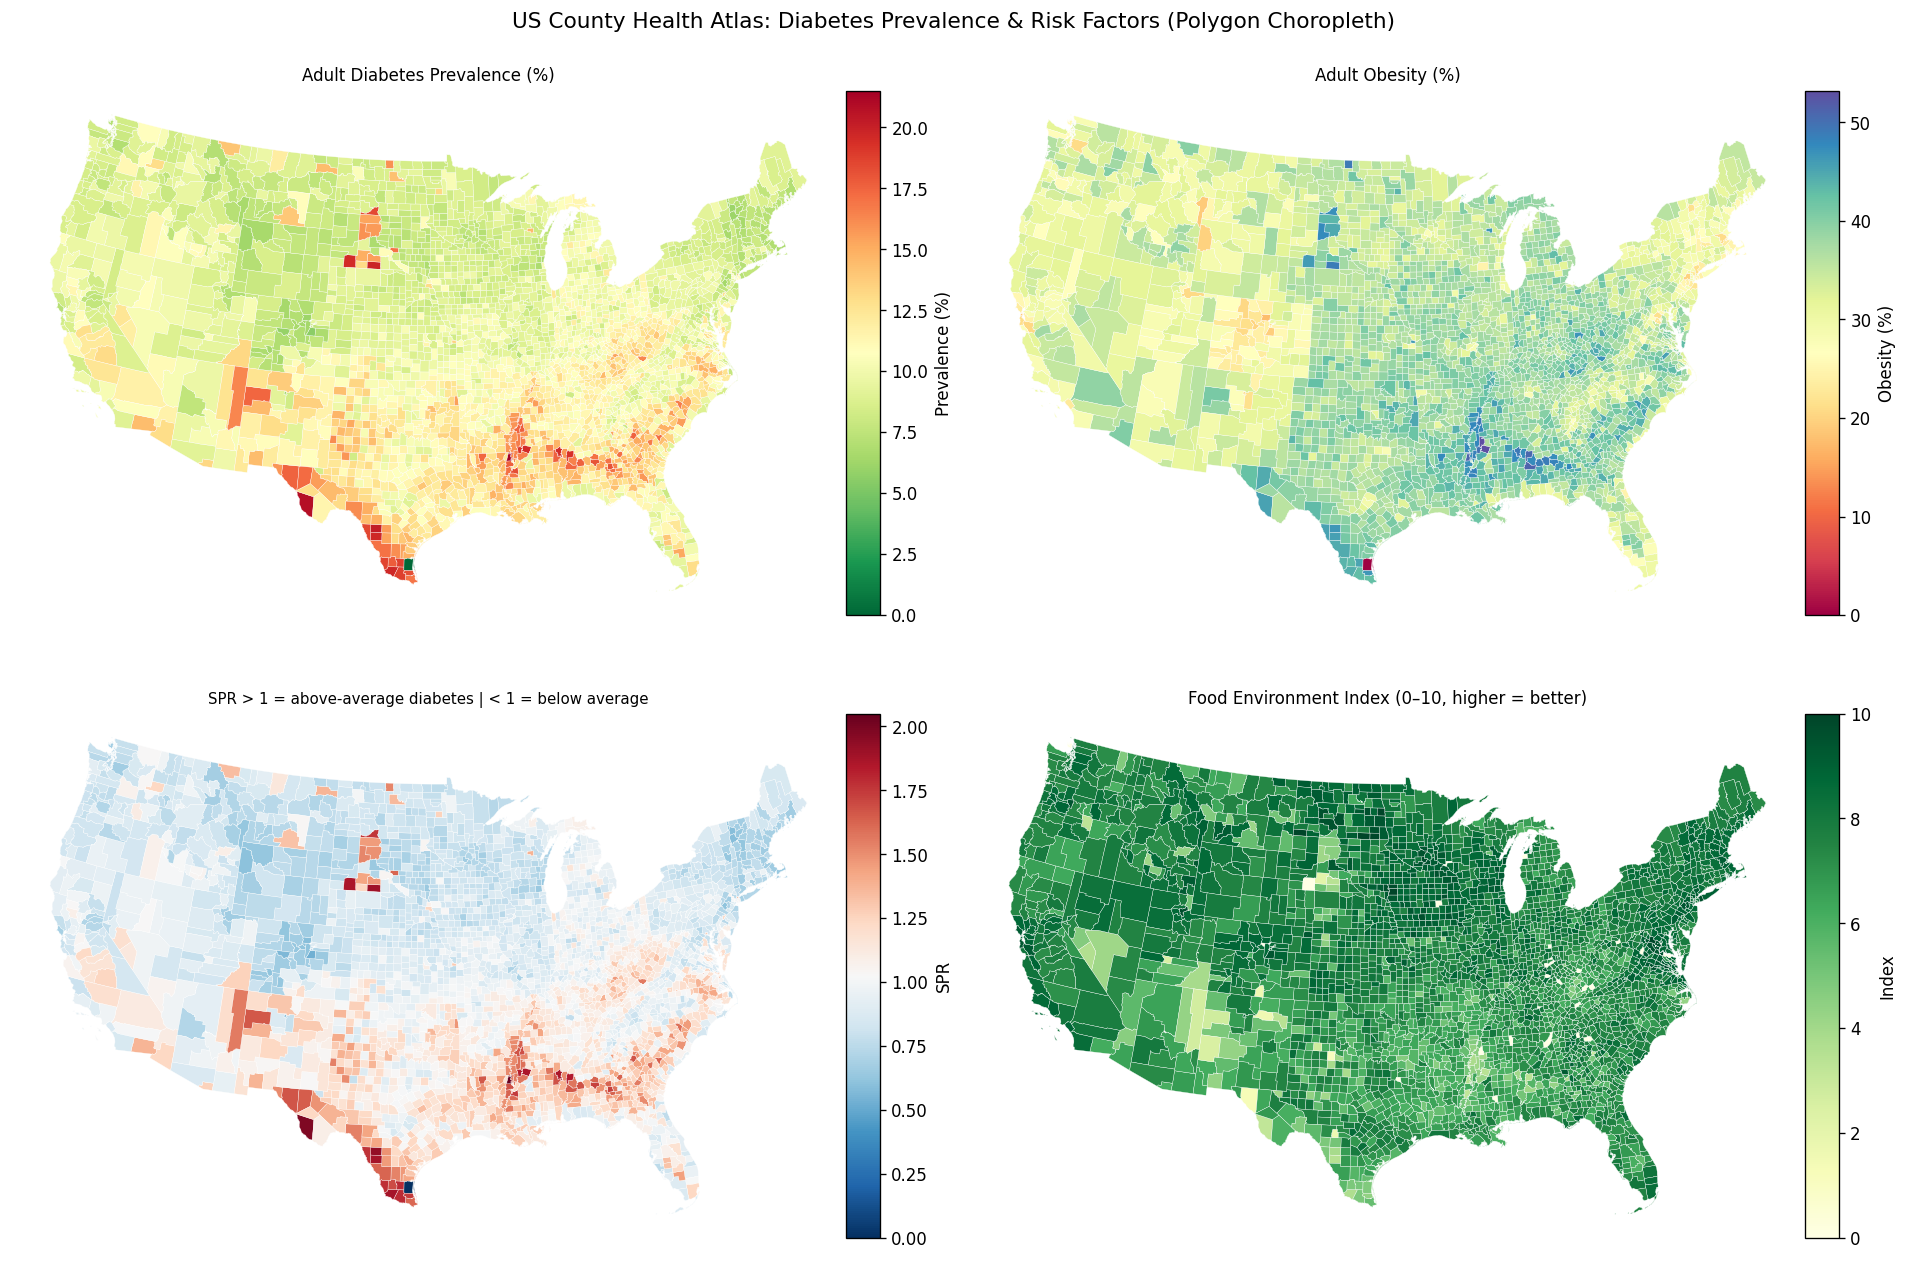

Counties with SPR > 1.2 (excess prevalence): 513 (16.5%)
Counties with SPR < 0.8 (deficit prevalence): 460 (14.8%)


In [3]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

def polygon_choropleth(ax, gdf, column, title, cmap="RdYlGn_r",
                       label="Rate (%)", n_quantiles=5, edgecolor="white"):
    """Polygon-based choropleth using quantile classification on a GeoDataFrame."""
    # Use quantile classification for bins
    quantiles = pd.qcut(gdf[column], n_quantiles, duplicates="drop")
    norm = mcolors.Normalize(vmin=gdf[column].min(), vmax=gdf[column].max())

    gdf.plot(column=column,
             cmap=cmap,
             linewidth=0.2,
             edgecolor=edgecolor,
             ax=ax,
             legend=False,
             norm=norm)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.01)
    cb = plt.colorbar(sm, cax=cax, label=label)
    ax.set_axis_off()
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Adult diabetes prevalence (polygon)
polygon_choropleth(axes[0,0], gdf, "diabetes_prev",
                   "Adult Diabetes Prevalence (%)", cmap="RdYlGn_r", label="Prevalence (%)")

# Obesity rate (polygon)
polygon_choropleth(axes[0,1], gdf, "pct_obesity",
                   "Adult Obesity (%)", cmap="Spectral", label="Obesity (%)")
              

# Standardised prevalence ratio (polygon)
polygon_choropleth(axes[1,0], gdf, "smr",
                   "Standardised Prevalence Ratio (county / national mean)", cmap="RdBu_r", label="SPR")
axes[1,0].set_title("SPR > 1 = above-average diabetes | < 1 = below average", fontsize=9)

# Food environment index (polygon)
polygon_choropleth(axes[1,1], gdf, "food_env_index",
                   "Food Environment Index (0–10, higher = better)", cmap="YlGn", label="Index")

plt.suptitle("US County Health Atlas: Diabetes Prevalence & Risk Factors (Polygon Choropleth)", fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/mod07/choropleth_atlas_polygon.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Counties with SPR > 1.2 (excess prevalence): {(gdf.smr>1.2).sum()} ({(gdf.smr>1.2).mean()*100:.1f}%)")
print(f"Counties with SPR < 0.8 (deficit prevalence): {(gdf.smr<0.8).sum()} ({(gdf.smr<0.8).mean()*100:.1f}%)")


## 4. Classification Schemes for Health Maps

There are multiple ways to classify continuous values into categories for health maps:
- Equal interval: Divides the range of data into categories with equal-sized intervals.
- Quantile: Splits the data so that each class contains the same number of observations (e.g., into quintiles).
- Natural Breaks (Jenks): Uses an algorithm to group values into classes that minimize within-class variance and maximize the difference between classes, often based on natural groupings in the data.


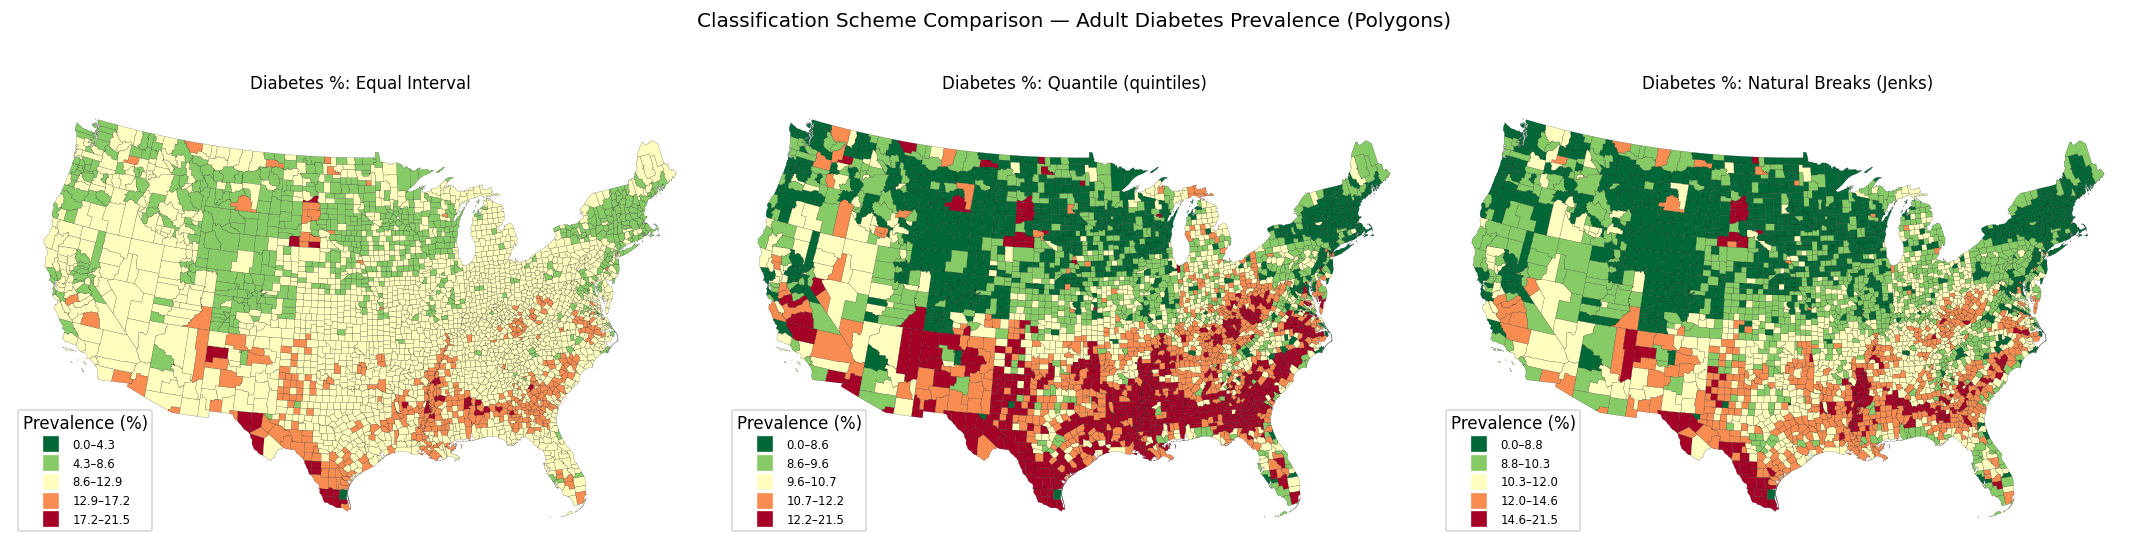

In [4]:
# Compare classification schemes using polygon data: Equal interval, Quantile, Natural Breaks (Jenks)
from scipy.cluster.vq import kmeans

def natural_breaks(values, k=5):
    """Simplified Jenks natural breaks via k-means on 1D data."""
    vals_1d = values.reshape(-1, 1).astype(float)
    centroids, _ = kmeans(vals_1d, k)
    centroids = np.sort(centroids.flatten())
    breaks = []
    for i in range(len(centroids) - 1):
        breaks.append((centroids[i] + centroids[i+1]) / 2)
    return [values.min()] + breaks + [values.max()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.cm.RdYlGn_r
n_classes = 5
outcome = gdf.diabetes_prev  # Use polygon (gdf) data

for ax, title, bins_fn in [
    (axes[0], "Equal Interval",
     lambda v: np.linspace(v.min(), v.max(), n_classes+1)),
    (axes[1], "Quantile (quintiles)",
     lambda v: np.percentile(v, np.linspace(0, 100, n_classes+1))),
    (axes[2], "Natural Breaks (Jenks)",
     lambda v: natural_breaks(v, n_classes)),
]:
    breaks = bins_fn(outcome.values)
    labels = pd.cut(outcome, bins=breaks, labels=False, include_lowest=True)
    colors = [cmap(labels.iloc[i]/(n_classes-1)) for i in range(len(gdf))]
    # Use full polygon geometries for plotting
    gdf.plot(ax=ax, color=colors, linewidth=0.1, edgecolor="k")
    ax.set_title(f"Diabetes %: {title}", fontsize=10)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    ax.set_axis_off()
    for k, (lo, hi) in enumerate(zip(breaks[:-1], breaks[1:])):
        ax.plot([], [], "s", color=cmap(k/(n_classes-1)),
                label=f"{lo:.1f}–{hi:.1f}", ms=8)
    ax.legend(fontsize=7, title="Prevalence (%)", loc="lower left")

plt.suptitle("Classification Scheme Comparison — Adult Diabetes Prevalence (Polygons)", fontsize=12)
plt.tight_layout()
plt.savefig("/tmp/mod07/classification_schemes.png", bbox_inches="tight")
plt.show()


## 5. Age Structure -  Crude vs Adjusted Prevalence

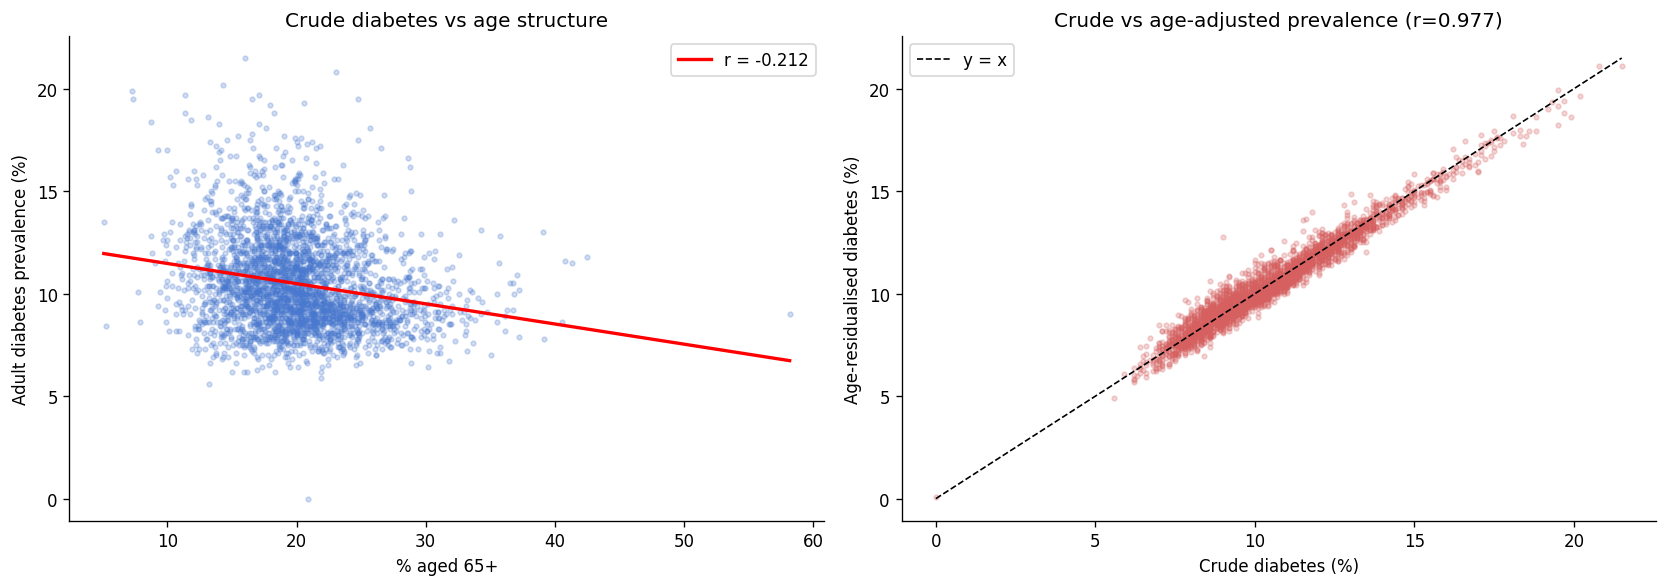

Counties where age-adjusted > crude (younger than expected for their rate): 1431 (46.0%)
Mean difference (age-adjusted − crude): -0.00 pp


In [5]:
# Age structure vs crude diabetes: % aged 65+ is observed, not simulated
m, b = np.polyfit(gdf.pct_65plus, gdf.diabetes_prev, 1)
gdf["diabetes_age_adj"] = (gdf.diabetes_prev - (m * gdf.pct_65plus + b)
                           + gdf.diabetes_prev.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(gdf.pct_65plus, gdf.diabetes_prev, alpha=0.25, s=8, color="#4878CF")
xl = np.linspace(gdf.pct_65plus.min(), gdf.pct_65plus.max(), 100)
axes[0].plot(xl, m*xl+b, "r-", lw=2,
             label=f"r = {np.corrcoef(gdf.pct_65plus, gdf.diabetes_prev)[0,1]:.3f}")
axes[0].set_xlabel("% aged 65+")
axes[0].set_ylabel("Adult diabetes prevalence (%)")
axes[0].set_title("Crude diabetes vs age structure")
axes[0].legend(fontsize=10)

axes[1].scatter(gdf.diabetes_prev, gdf.diabetes_age_adj, alpha=0.25, s=8, color="#D65F5F")
lims = [gdf.diabetes_prev.min(), gdf.diabetes_prev.max()]
axes[1].plot(lims, lims, "k--", lw=1, label="y = x")
r_adj = np.corrcoef(gdf.diabetes_prev, gdf.diabetes_age_adj)[0,1]
axes[1].set_xlabel("Crude diabetes (%)")
axes[1].set_ylabel("Age-residualised diabetes (%)")
axes[1].set_title(f"Crude vs age-adjusted prevalence (r={r_adj:.3f})")
axes[1].legend(fontsize=10)
plt.tight_layout()
plt.savefig("/tmp/mod07/crude_vs_asmr.png", bbox_inches="tight")
plt.show()

diff = gdf.diabetes_age_adj - gdf.diabetes_prev
print(f"Counties where age-adjusted > crude (younger than expected for their rate): "
      f"{(diff>0).sum()} ({(diff>0).mean()*100:.1f}%)")
print(f"Mean difference (age-adjusted − crude): {diff.mean():.2f} pp")


## 6. Spatial Join -  Linking Point Data to Polygons

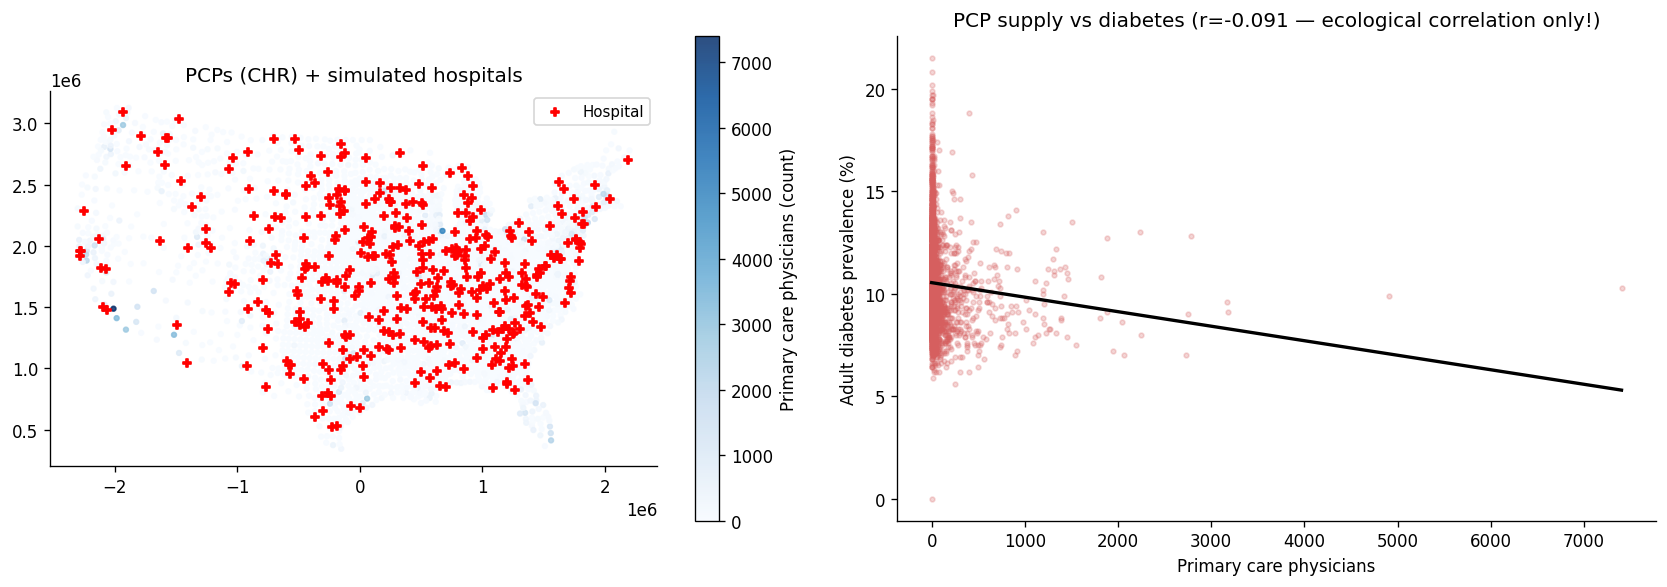

In [6]:
# Simulate hospital locations (point data) using more realistic distribution based on county populations
# and spatial locations from gdf (counties as polygons). Then join to nearest county centroid.

np.random.seed(13)
N_HOSPITALS = 400

# Use gdf for spatial distribution: weights by population (or population density if present)
if "population" in gdf.columns:
    weights = gdf["population"] / gdf["population"].sum()
else:
    # As a fallback, use an approx uniform distribution
    weights = np.ones(len(gdf)) / len(gdf)

# Sample counties for hospital locations with population weighting
hospital_county_indices = np.random.choice(gdf.index, size=N_HOSPITALS, p=weights)

# Get x, y coordinates as hospital locations within each selected county
hosp_lon = []
hosp_lat = []
for idx in hospital_county_indices:
    # Place hospital randomly within the county polygon if polygons are valid
    try:
        polygon = gdf.loc[idx, "geometry"]
        minx, miny, maxx, maxy = polygon.bounds
        for _ in range(10):  # up to 10 attempts
            x = np.random.uniform(minx, maxx)
            y = np.random.uniform(miny, maxy)
            if polygon.contains(Point(x, y)):
                hosp_lon.append(x)
                hosp_lat.append(y)
                break
        else:
            # fallback to centroid if random point did not succeed
            centroid = polygon.centroid
            hosp_lon.append(centroid.x)
            hosp_lat.append(centroid.y)
    except Exception:
        # If geometry is not valid, fallback to centroid from gdf
        centroid = gdf.loc[idx, "geometry"].centroid
        hosp_lon.append(centroid.x)
        hosp_lat.append(centroid.y)

hosp_lon = np.array(hosp_lon)
hosp_lat = np.array(hosp_lat)

# Simulate hospital beds with a modest size-biased distribution (larger counties tend to have bigger hospitals)
selected_county_pops = gdf.loc[hospital_county_indices, "population"].values if "population" in gdf.columns else np.ones(N_HOSPITALS)
beds_mean = 100 + (selected_county_pops / selected_county_pops.max()) * 700  # more beds in populous counties
hosp_beds = np.random.lognormal(mean=np.log(beds_mean), sigma=0.4).astype(int).clip(50, 1500)

# Simulate trauma center presence more likely in more populated counties
trauma_probs = np.clip(selected_county_pops / selected_county_pops.max() * 0.6, 0.2, 0.7)
hosp_trauma = np.random.binomial(1, trauma_probs)

from scipy.spatial import cKDTree
county_centroids = gdf.geometry.centroid
county_coords = np.column_stack([county_centroids.x, county_centroids.y])
hosp_coords   = np.column_stack([hosp_lon, hosp_lat])
tree = cKDTree(county_coords)
_, county_idx = tree.query(hosp_coords)

# Reset hospital counts in gdf first
gdf["n_hospitals"]    = 0
gdf["total_beds"]     = 0
gdf["has_trauma_ctr"] = 0
for i, c_idx in enumerate(county_idx):
    gdf.iloc[c_idx, gdf.columns.get_loc("n_hospitals")]    += 1
    gdf.iloc[c_idx, gdf.columns.get_loc("total_beds")]     += hosp_beds[i]
    gdf.iloc[c_idx, gdf.columns.get_loc("has_trauma_ctr")] += hosp_trauma[i]
gdf["has_trauma_ctr"] = (gdf["has_trauma_ctr"] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot counties colored by primary care physicians, overlay hospitals
scatter_c = axes[0].scatter(gdf.geometry.centroid.x, gdf.geometry.centroid.y,
                            c=gdf.n_pcp, cmap="Blues", s=8, alpha=0.85)
axes[0].scatter(hosp_lon, hosp_lat, marker="P", s=18, c="red", zorder=5, label="Hospital")
plt.colorbar(scatter_c, ax=axes[0], label="Primary care physicians (count)")
axes[0].set_title("PCPs (CHR) + simulated hospitals")
axes[0].legend(fontsize=9)
axes[0].set_aspect("equal", adjustable="box")

# Correlation plot - using updated gdf
corr = np.corrcoef(gdf.n_pcp, gdf.diabetes_prev)[0,1]
axes[1].scatter(gdf.n_pcp, gdf.diabetes_prev, alpha=0.25, s=8, color="#D65F5F")
m, b = np.polyfit(gdf.n_pcp, gdf.diabetes_prev, 1)
xl = np.linspace(gdf.n_pcp.min(), gdf.n_pcp.max(), 100)
axes[1].plot(xl, m*xl+b, "k-", lw=2)
axes[1].set_xlabel("Primary care physicians")
axes[1].set_ylabel("Adult diabetes prevalence (%)")
axes[1].set_title(f"PCP supply vs diabetes (r={corr:.3f} — ecological correlation only!)")
plt.tight_layout()
plt.savefig("/tmp/mod07/hospital_join.png", bbox_inches="tight")
plt.show()


## 7. Knowledge Check
1. A choropleth map uses quantile classification and shows your county in the highest quintile. A colleague uses equal-interval and shows it in the 4th class. Which is "correct"?
2. SPR = 1.45 for a rural county (diabetes / national mean). What does this mean, and what information do you need to know if this is statistically significant?
3. You want to map diabetes prevalence for census tracts. Your denominator (population) comes from the 2020 Census but your numerator covers 2018–2022. What are the key assumptions?
4. The correlation between PCP count and diabetes prevalence is negative. A colleague concludes "more doctors reduce diabetes." What fallacy is this?
5. Compute a bivariate choropleth: classify counties into 3×3 cells by both obesity and diabetes prevalence, and colour-code the 9 combinations.


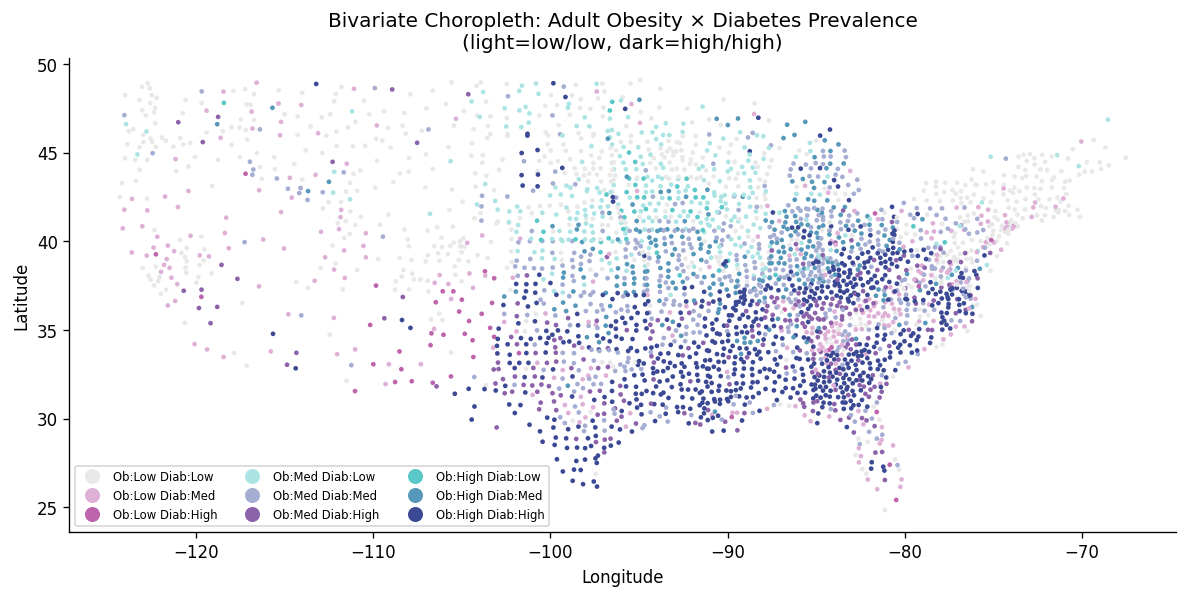

In [7]:
# Exercise 5 — Bivariate choropleth (3x3 = 9 classes)
obesity_cat = pd.qcut(df.pct_obesity, 3, labels=[0,1,2], duplicates="drop")
diab_cat    = pd.qcut(df.diabetes_prev, 3, labels=[0,1,2], duplicates="drop")
bivariate_class = obesity_cat.astype(int) * 3 + diab_cat.astype(int)

# 9-colour palette (low-low=light, high-high=dark)
biv_colors = {
    0:"#e8e8e8",1:"#dfb0d6",2:"#be64ac",   # low obesity
    3:"#ace4e4",4:"#a5add3",5:"#8c62aa",   # mid obesity
    6:"#5ac8c8",7:"#5698b9",8:"#3b4994",   # high obesity
}
colors_biv = [biv_colors[c] for c in bivariate_class]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df.lon, df.lat, c=colors_biv, s=8, edgecolors="none")
ax.set_title("Bivariate Choropleth: Adult Obesity × Diabetes Prevalence\n"
             "(light=low/low, dark=high/high)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
for cls, color in biv_colors.items():
    ob_lbl = ["Low","Med","High"][cls//3]
    db_lbl = ["Low","Med","High"][cls%3]
    ax.plot([],[],"o",color=color,ms=8,label=f"Ob:{ob_lbl} Diab:{db_lbl}")
ax.legend(ncol=3, fontsize=7, loc="lower left")
plt.tight_layout()
plt.savefig("/tmp/mod07/bivariate_choropleth.png", bbox_inches="tight")
plt.show()


***
**Next → NB-02: Spatial Autocorrelation & Moran's I**
